# 03 · MAP reconstruction  *(Wednesday deliverable)*

Plug the frozen decoder into NumPyro and find the MAP latent with SVI:

```
z ~ N(0, I)          x = decoder(z)          y = M ⊙ fft2c(x) + noise
```

SVI with an `AutoDelta` guide finds the single most probable `z`; decoding it
gives the MAP image. We then compare it against the baselines on the **same**
measurement.

Two things this notebook is careful about, because they are the difference
between a real result and a flattering one:

- **The slice is held out.** `split='val'` is a volume the VAE never saw. A
  reconstruction of a training slice tells you nothing.
- **Zero-filled is a strong baseline at these accelerations.** The mask keeps a
  fully-sampled ACS band, and a knee image has most of its energy in those low
  frequencies, so zero-filling already scores well at R = 4. The prior has to
  earn its place — and it earns it at higher R, where more of k-space is
  missing. That is why we run both R = 4 and R = 8.

In [1]:
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np

from mrigen import metrics, viz
from mrigen.data import FastMRISlices
from mrigen.evaluate import measure
from mrigen.masks import equispaced_mask
from mrigen.recon.classical import tv_fista, zero_filled
from mrigen.recon.operators import data_consistency
from mrigen.recon.vae_numpyro import reconstruct_map
from mrigen.train_vae import load_model

SIGMA = 0.01  # measurement noise, shared by every method

In [2]:
vae = load_model('../checkpoints/vae_128.eqx', latent_dim=128)

# A held-out volume, and a central slice: the first and last slices of a knee
# volume are mostly air and flatter any method that returns a smooth image.
test = FastMRISlices('../data/processed', split='val')
print(f"val split: {len(test)} slices from {test.volumes}")
x = jnp.asarray(test[len(test) // 2])

masks = {R: equispaced_mask((128, 128), acceleration=R) for R in (4, 8)}
for R, m in masks.items():
    print(f"R = {R} nominal -> {float(m.size / m.sum()):.2f}x effective "
          f"({int(m[0].sum())}/{m.shape[1]} columns kept)")

val split: 36 slices from ['file1000593']


R = 4 nominal -> 3.28x effective (39/128 columns kept)
R = 8 nominal -> 5.12x effective (25/128 columns kept)


In [3]:
gt = np.asarray(x)
rows = {}

for R, mask in masks.items():
    # One measurement per R, shared by every method, from a fixed key.
    y = measure(x, mask, SIGMA, jax.random.PRNGKey(R))

    x_zf = np.asarray(zero_filled(y, mask))
    x_tv = np.asarray(tv_fista(y, mask, lam=1e-3, n_iter=100))
    x_map, z_map = reconstruct_map(y, mask, vae.decoder, vae.latent_dim,
                                   sigma=SIGMA, steps=2000, lr=1e-2)
    # Data consistency: keep the k-space lines the scanner actually measured,
    # let the decoder fill only the gaps.
    x_dc = np.asarray(data_consistency(x_map, y, mask))
    x_map = np.asarray(x_map)

    recons = {'zero-filled': x_zf, 'TV/L1': x_tv,
              'VAE MAP': x_map, 'VAE MAP + DC': x_dc}
    rows[R] = recons

    print(f"\nR = {R} ({float(mask.size / mask.sum()):.2f}x effective), held-out slice")
    print(f"  {'method':<16} {'PSNR (dB)':>10} {'SSIM':>7} {'NMSE':>8}")
    for name, r in recons.items():
        print(f"  {name:<16} {metrics.psnr(gt, r, data_range=1.0):>10.2f} "
              f"{metrics.ssim(gt, r, data_range=1.0):>7.3f} "
              f"{metrics.nmse(gt, r):>8.4f}")
    print(f"  ||z_map|| = {float(jnp.linalg.norm(z_map)):.1f} "
          f"(a typical draw from N(0, I) in {vae.latent_dim}d has norm "
          f"{np.sqrt(vae.latent_dim):.1f} — far above it means the MAP latent "
          f"is off the prior)")

  0%|          | 0/2000 [00:00<?, ?it/s]

  0%|          | 1/2000 [00:00<16:44,  1.99it/s]

  1%|          | 15/2000 [00:00<01:01, 32.53it/s]

  1%|▏         | 29/2000 [00:00<00:34, 57.52it/s]

  2%|▏         | 44/2000 [00:00<00:24, 80.86it/s]

...

 98%|█████████▊| 1964/2000 [00:16<00:00, 117.85it/s, init loss: 1482078.7500, avg. loss [1801-1900]: 242122.8750]

 99%|█████████▉| 1978/2000 [00:16<00:00, 122.19it/s, init loss: 1482078.7500, avg. loss [1801-1900]: 242122.8750]

100%|█████████▉| 1991/2000 [00:16<00:00, 121.71it/s, init loss: 1482078.7500, avg. loss [1801-1900]: 242122.8750]

100%|██████████| 2000/2000 [00:16<00:00, 121.50it/s, init loss: 1482078.7500, avg. loss [1901-2000]: 242103.8594]


R = 8 (5.12x effective), held-out slice
  method            PSNR (dB)    SSIM     NMSE
  zero-filled           23.35   0.536   0.0455
  TV/L1                 24.21   0.586   0.0373
  VAE MAP               20.77   0.403   0.0824
  VAE MAP + DC          22.99   0.529   0.0494
  ||z_map|| = 8.8 (a typical draw from N(0, I) in 128d has norm 11.3 — far above it means the MAP latent is off the prior)


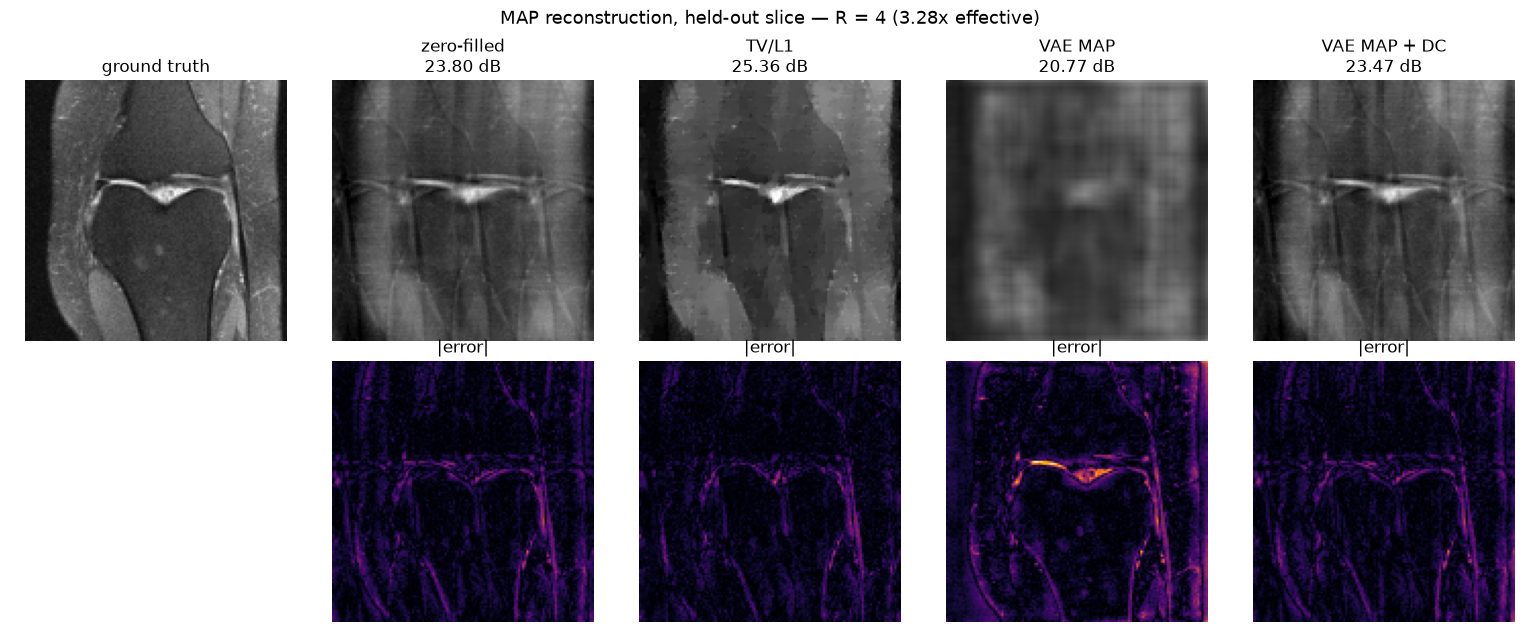

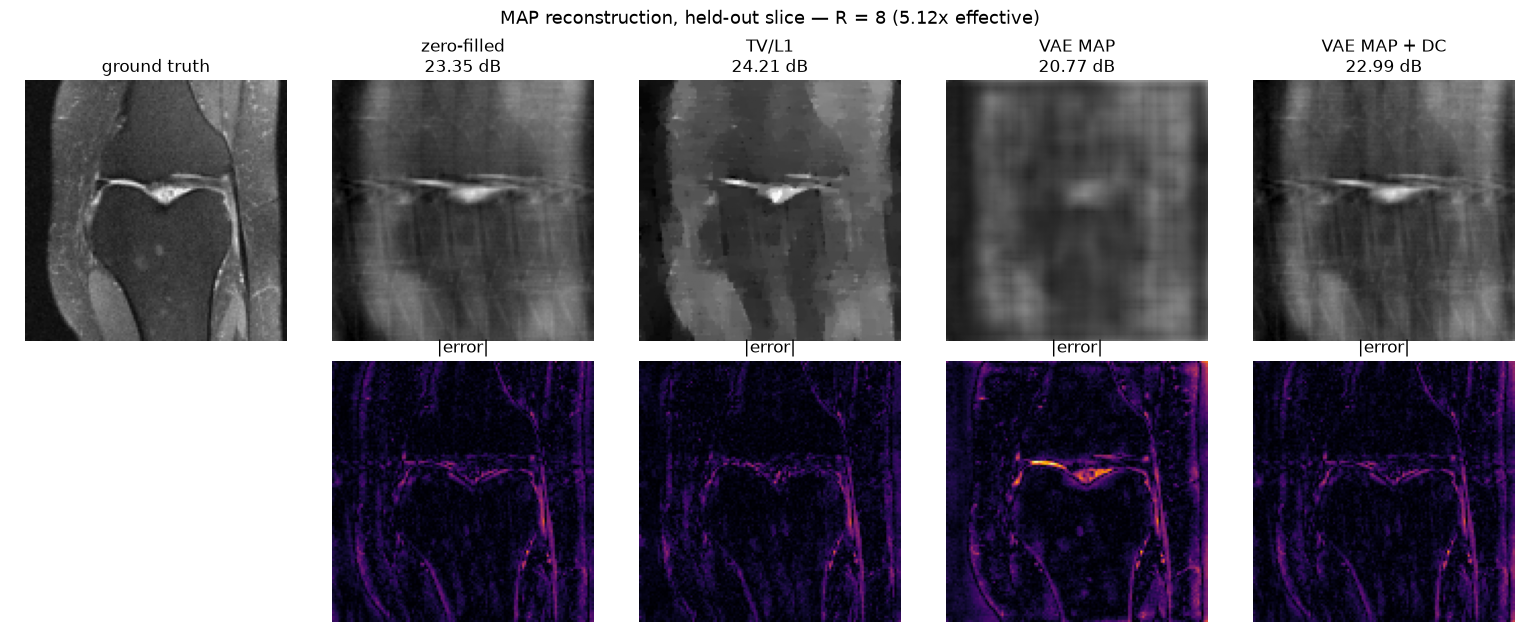

In [4]:
# Ground truth, every method, and the error map under each one — on a shared
# colour scale, so the panels are comparable by eye and not just by number.
for R, recons in rows.items():
    names = list(recons)
    fig, ax = plt.subplots(2, len(names) + 1, figsize=(3.1 * (len(names) + 1), 6.4))
    err_max = max(np.abs(r - gt).max() for r in recons.values())

    viz.show_image(gt, ax[0, 0], title='ground truth', vmin=0, vmax=1)
    ax[1, 0].axis('off')
    for j, name in enumerate(names, start=1):
        r = recons[name]
        viz.show_image(r, ax[0, j], vmin=0, vmax=1,
                       title=f"{name}\n{metrics.psnr(gt, r, data_range=1.0):.2f} dB")
        ax[1, j].imshow(np.abs(r - gt), cmap='inferno', vmin=0, vmax=err_max)
        ax[1, j].set_title('|error|')
        ax[1, j].axis('off')

    fig.suptitle(f"MAP reconstruction, held-out slice — R = {R} "
                 f"({float(masks[R].size / masks[R].sum()):.2f}x effective)",
                 fontsize=13)
    fig.tight_layout()
    fig.savefig(f"recon_map_R{R}.png", dpi=150, bbox_inches='tight')
plt.show()